In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
import joblib
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
# Load the required CSV files
orders = pd.read_csv(r'D:\PowerBI\olist-project\data\olist_orders_dataset.csv')
order_items = pd.read_csv(r'D:\PowerBI\olist-project\data\olist_order_items_dataset.csv')
customers = pd.read_csv(r'D:\PowerBI\olist-project\data\olist_customers_dataset.csv')
sellers = pd.read_csv(r'D:\PowerBI\olist-project\data\olist_sellers_dataset.csv')
products = pd.read_csv(r'D:\PowerBI\olist-project\data\olist_products_dataset.csv')

print("Orders shape:", orders.shape)
print("Order Items shape:", order_items.shape)
print("Customers shape:", customers.shape)
print("Sellers shape:", sellers.shape)
print("Products shape:", products.shape)

Orders shape: (99441, 8)
Order Items shape: (112650, 7)
Customers shape: (99441, 5)
Sellers shape: (3095, 4)
Products shape: (32951, 9)


In [4]:
# Step 1 — Merge orders with order_items
df = orders.merge(order_items, on='order_id', how='inner')

# Step 2 — Merge with customers
df = df.merge(customers, on='customer_id', how='inner')

# Step 3 — Merge with sellers
df = df.merge(sellers, on='seller_id', how='inner')

# Step 4 — Merge with products
df = df.merge(products, on='product_id', how='inner')

print("Merged DataFrame shape:", df.shape)
print("\nColumns available:")
print(df.columns.tolist())

Merged DataFrame shape: (112650, 29)

Columns available:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'product_category_name', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']


In [5]:
# Convert date columns to datetime
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_approved_at'] = pd.to_datetime(df['order_approved_at'])

# Create target column — is_late (1 = Late, 0 = On Time)
df['is_late'] = (df['order_delivered_customer_date'] > df['order_estimated_delivery_date']).astype(int)

# Check the distribution
print("Delivery Status Distribution:")
print(df['is_late'].value_counts())
print("\nPercentage:")
print(df['is_late'].value_counts(normalize=True) * 100)

Delivery Status Distribution:
is_late
0    103935
1      8715
Name: count, dtype: int64

Percentage:
is_late
0    92.263648
1     7.736352
Name: proportion, dtype: float64


In [6]:
# Select only delivered orders (we know the actual delivery date)
df = df[df['order_status'] == 'delivered'].copy()

# Select relevant features for the model
features = [
    'price',
    'freight_value',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm',
    'product_photos_qty',
    'customer_state',
    'seller_state',
    'is_late'  # target column
]

# Keep only selected columns
df_model = df[features].copy()

# Check missing values
print("Missing values per column:")
print(df_model.isnull().sum())
print("\nDataset shape after filtering:", df_model.shape)

Missing values per column:
price                    0
freight_value            0
product_weight_g        18
product_length_cm       18
product_height_cm       18
product_width_cm        18
product_photos_qty    1537
customer_state           0
seller_state             0
is_late                  0
dtype: int64

Dataset shape after filtering: (110197, 10)


In [7]:
# Fill missing numerical values with median
df_model['product_weight_g'].fillna(df_model['product_weight_g'].median(), inplace=True)
df_model['product_length_cm'].fillna(df_model['product_length_cm'].median(), inplace=True)
df_model['product_height_cm'].fillna(df_model['product_height_cm'].median(), inplace=True)
df_model['product_width_cm'].fillna(df_model['product_width_cm'].median(), inplace=True)
df_model['product_photos_qty'].fillna(df_model['product_photos_qty'].median(), inplace=True)

# Encode categorical columns (customer_state, seller_state)
le = LabelEncoder()
df_model['customer_state'] = le.fit_transform(df_model['customer_state'])
df_model['seller_state'] = le.fit_transform(df_model['seller_state'])

# Verify no missing values remain
print("Missing values after cleaning:")
print(df_model.isnull().sum())
print("\nFinal dataset shape:", df_model.shape)
print("\nSample data:")
print(df_model.head())

Missing values after cleaning:
price                 0
freight_value         0
product_weight_g      0
product_length_cm     0
product_height_cm     0
product_width_cm      0
product_photos_qty    0
customer_state        0
seller_state          0
is_late               0
dtype: int64

Final dataset shape: (110197, 10)

Sample data:
    price  freight_value  product_weight_g  product_length_cm  \
0   29.99           8.72             500.0               19.0   
1  118.70          22.76             400.0               19.0   
2  159.90          19.22             420.0               24.0   
3   45.00          27.20             450.0               30.0   
4   19.90           8.72             250.0               51.0   

   product_height_cm  product_width_cm  product_photos_qty  customer_state  \
0                8.0              13.0                 4.0              25   
1               13.0              19.0                 1.0               4   
2               19.0              21.0    

In [8]:
from sklearn.utils import resample

# Separate features and target
X = df_model.drop('is_late', axis=1)
y = df_model['is_late']

# Handle imbalanced dataset using oversampling
# Combine X and y for resampling
df_combined = pd.concat([X, y], axis=1)

# Separate majority and minority classes
majority = df_combined[df_combined['is_late'] == 0]
minority = df_combined[df_combined['is_late'] == 1]

# Oversample minority class to match majority
minority_oversampled = resample(minority,
                                replace=True,
                                n_samples=len(majority),
                                random_state=42)

# Combine back
df_balanced = pd.concat([majority, minority_oversampled])

# Separate X and y again
X_balanced = df_balanced.drop('is_late', axis=1)
y_balanced = df_balanced['is_late']

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)
print("\nClass distribution after balancing:")
print(y_balanced.value_counts())

Training set shape: (162372, 9)
Testing set shape: (40594, 9)

Class distribution after balancing:
is_late
0    101483
1    101483
Name: count, dtype: int64


In [9]:
from sklearn.preprocessing import StandardScaler

# Scale the features (important for Logistic Regression)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)

# Predictions
lr_predictions = lr_model.predict(X_test_scaled)

# Results
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)
print("\nAccuracy:", round(accuracy_score(y_test, lr_predictions) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, lr_predictions, 
      target_names=['On Time', 'Late']))

LOGISTIC REGRESSION RESULTS

Accuracy: 56.57 %

Classification Report:
              precision    recall  f1-score   support

     On Time       0.56      0.62      0.59     20219
        Late       0.58      0.51      0.54     20375

    accuracy                           0.57     40594
   macro avg       0.57      0.57      0.56     40594
weighted avg       0.57      0.57      0.56     40594



In [11]:
# Train Random Forest (no scaling needed)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

# Predictions
rf_predictions = rf_model.predict(X_test)

# Results
print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)
print("\nAccuracy:", round(accuracy_score(y_test, rf_predictions) * 100, 2), "%")
print("\nClassification Report:")
print(classification_report(y_test, rf_predictions,
      target_names=['On Time', 'Late']))

RANDOM FOREST RESULTS

Accuracy: 69.22 %

Classification Report:
              precision    recall  f1-score   support

     On Time       0.69      0.70      0.69     20219
        Late       0.70      0.69      0.69     20375

    accuracy                           0.69     40594
   macro avg       0.69      0.69      0.69     40594
weighted avg       0.69      0.69      0.69     40594



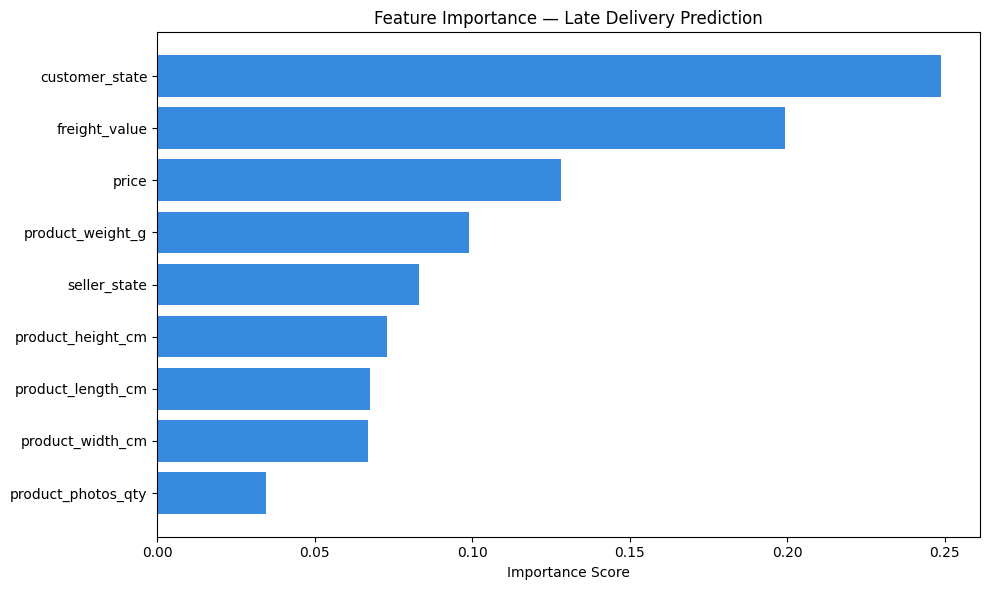


Feature Importance Scores:
              Feature  Importance
7      customer_state    0.248811
1       freight_value    0.199364
0               price    0.128076
2    product_weight_g    0.098926
8        seller_state    0.083093
4   product_height_cm    0.072851
3   product_length_cm    0.067481
5    product_width_cm    0.066995
6  product_photos_qty    0.034403


In [12]:
# Get feature importances from Random Forest
feature_names = X_train.columns.tolist()
importances = rf_model.feature_importances_

# Create a DataFrame for visualization
feat_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=True)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(feat_df['Feature'], feat_df['Importance'], color='#378ADD')
plt.xlabel('Importance Score')
plt.title('Feature Importance — Late Delivery Prediction')
plt.tight_layout()
plt.savefig(r'D:\PowerBI\olist-project\phase6_ml\feature_importance.png', dpi=150)
plt.show()

print("\nFeature Importance Scores:")
print(feat_df.sort_values('Importance', ascending=False))

# Phase 6 — Late Delivery Prediction: ML Model Insights

## Model Performance Summary

| Model | Accuracy | Precision (Late) | Recall (Late) | F1 Score (Late) |
|-------|----------|-----------------|---------------|-----------------|
| Logistic Regression | 56.57% | 0.58 | 0.51 | 0.54 |
| Random Forest | **69.22%** | **0.70** | **0.69** | **0.69** |

✅ **Winner: Random Forest** — captures complex non-linear relationships between features

---

## Feature Importance Insights

| Rank | Feature | Importance | Business Meaning |
|------|---------|------------|-----------------|
| 1 | customer_state | 24.88% | Customer location is the #1 driver of late deliveries |
| 2 | freight_value | 19.94% | Higher freight = longer distance = higher delay risk |
| 3 | price | 12.81% | Expensive items require special handling |
| 4 | product_weight_g | 9.89% | Heavier products are harder to transport quickly |
| 5 | seller_state | 8.31% | Seller location significantly impacts delivery time |
| 6 | product_height_cm | 7.29% | Bulky products create logistics challenges |
| 7 | product_length_cm | 6.75% | Product size affects transport capacity |
| 8 | product_width_cm | 6.70% | Product size affects transport capacity |
| 9 | product_photos_qty | 3.44% | Listing quality has minimal impact on delivery |

---

## Key Business Insights

### 🌍 Insight 1 — Geography Drives Delays (24.88%)
> Customer location is the **single biggest predictor** of late delivery.
> Remote states like **AM, RR, AP** face consistent last mile delivery challenges
> due to poor infrastructure and long distances from seller hubs.

### 🚚 Insight 2 — Freight Value Confirms Distance Problem (19.94%)
> High freight value directly correlates with long distance shipments.
> This connects to **SQL Day 1 findings** — states with highest delivery
> delays also have the highest freight values.

### 📦 Insight 3 — Product Size Matters (43% combined)
> Weight + all dimensions together account for **43% of importance**.
> Heavy and bulky products are consistently delivered late —
> logistics network struggles with large item handling.

### 📸 Insight 4 — Photos Don't Affect Delivery (3.44%)
> Product listing quality has almost **zero impact** on delivery performance.
> Late deliveries are purely a **logistics problem** — not a seller quality problem.

---

## Project Story Connection

In [13]:
# Save the Random Forest model
joblib.dump(rf_model, r'D:\PowerBI\olist-project\phase6_ml\late_delivery_model.pkl')
joblib.dump(scaler, r'D:\PowerBI\olist-project\phase6_ml\scaler.pkl')

print("Model saved successfully!")
print("\nFiles saved:")
print("- late_delivery_model.pkl")
print("- scaler.pkl")

# Final Model Summary
print("\n" + "=" * 50)
print("PHASE 6 — ML MODEL SUMMARY")
print("=" * 50)
print(f"Total records used     : 110,197")
print(f"Features used          : 9")
print(f"Training set size      : 162,372 (after balancing)")
print(f"Testing set size       : 40,594")
print(f"Logistic Regression    : 56.57% accuracy")
print(f"Random Forest          : 69.22% accuracy")
print(f"Best Model             : Random Forest")
print(f"Top predictor          : customer_state (24.88%)")

Model saved successfully!

Files saved:
- late_delivery_model.pkl
- scaler.pkl

PHASE 6 — ML MODEL SUMMARY
Total records used     : 110,197
Features used          : 9
Training set size      : 162,372 (after balancing)
Testing set size       : 40,594
Logistic Regression    : 56.57% accuracy
Random Forest          : 69.22% accuracy
Best Model             : Random Forest
Top predictor          : customer_state (24.88%)
